<a href="https://colab.research.google.com/github/anujpurohit0501/Loan_Prediction/blob/main/Loan_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    -Loan Amount Prediction using Machine Learning



##### **Project Type**    - EDA/Regression
##### **Contribution** -Individual
##### **Name**            - Anuj Purohit

# **Project Summary -**

The Loan Amount Prediction project uses Machine Learning to estimate loan amounts based on applicant financial and demographic details. The data was cleaned, analyzed, and preprocessed using techniques like missing value handling, outlier treatment, and encoding.

Multiple regression models were compared using evaluation metrics, and the best model was selected after tuning. The solution helps financial institutions make faster and more reliable loan decisions through data-driven predictions.

# **GitHub Link -**

https://github.com/anujpurohit0501

# **Problem Statement**


**Write Problem Statement Here.**

Banks and financial institutions receive a large number of loan applications from customers having different financial backgrounds. Determining the appropriate loan amount for every applicant through manual analysis is time-consuming and may lead to inconsistent decisions.

The objective of this project is to develop a Machine Learning model capable of predicting the loan amount based on applicant details such as income, education, marital status, credit history, employment status, dependents, property area, and loan term.

The project focuses on cleaning the dataset, performing exploratory data analysis, preprocessing the data, building multiple regression models, evaluating their performance, and selecting the most accurate model for predicting loan amounts.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [100]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



### Dataset Loading

In [101]:
# Load Dataset


path ='/content/test_Y3wMUE5_7gLdaTN.csv'


df=pd.read_csv(path)

### Dataset First View

In [102]:
# Dataset First Look
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,Male,Yes,0,Graduate,No,5720,0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500,126.0,360.0,1.0,Urban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800,208.0,360.0,1.0,Urban
3,LP001035,Male,Yes,2,Graduate,No,2340,2546,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0,78.0,360.0,1.0,Urban


### Dataset Rows & Columns count

In [103]:
# Dataset Rows & Columns count
df.shape

(367, 12)

### Dataset Information

In [104]:
# Dataset Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            367 non-null    object 
 1   Gender             356 non-null    object 
 2   Married            367 non-null    object 
 3   Dependents         357 non-null    object 
 4   Education          367 non-null    object 
 5   Self_Employed      344 non-null    object 
 6   ApplicantIncome    367 non-null    int64  
 7   CoapplicantIncome  367 non-null    int64  
 8   LoanAmount         362 non-null    float64
 9   Loan_Amount_Term   361 non-null    float64
 10  Credit_History     338 non-null    float64
 11  Property_Area      367 non-null    object 
dtypes: float64(3), int64(2), object(7)
memory usage: 34.5+ KB


#### Duplicate Values

In [105]:
# Dataset Duplicate Value Count
df.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [106]:
# Missing Values/Null Values Count
df.isnull().sum()
df = df.drop_duplicates()

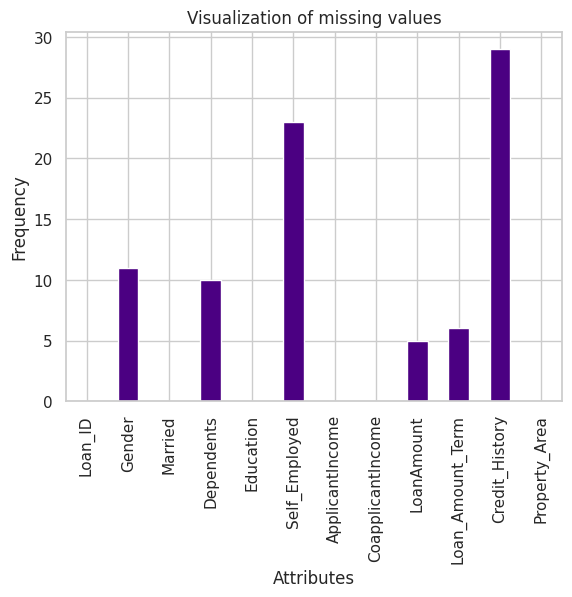

In [107]:
# Visualizing the missing values
x=df.isnull().sum()
x.plot(kind='bar',color='indigo')
plt.xlabel('Attributes')
plt.ylabel('Frequency')
plt.title('Visualization of missing values')
plt.show()


### What did you know about your dataset?

Answer : I found duplicate records and some missing values in certain columns. Visualizing them helped identify data quality issues and guided the cleaning process before analysis.

## ***2. Understanding Your Variables***

In [108]:
# Dataset Columns
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [109]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,367.000000,367.000000,362.000000,361.000000,338.000000
mean,4805.599455,1569.577657,136.132597,342.537396,0.825444
std,4910.685399,2334.232099,61.366652,65.156643,0.380150
min,0.000000,0.000000,28.000000,6.000000,0.000000
25%,2864.000000,0.000000,100.250000,360.000000,1.000000
50%,3786.000000,1025.000000,125.000000,360.000000,1.000000
75%,5060.000000,2430.500000,158.000000,360.000000,1.000000
max,72529.000000,24000.000000,550.000000,480.000000,1.000000


### Variables Description

Loan_ID : Unique identification number of each loan application.

Gender : Gender of the applicant.

Married : Marital status of the applicant.

Dependents : Number of dependents.

Education : Educational qualification of the applicant.

Self_Employed : Whether the applicant is self-employed.

ApplicantIncome : Monthly income of the primary applicant.

CoapplicantIncome : Monthly income of the co-applicant.

LoanAmount : Loan amount requested by the applicant (Target Variable).

Loan_Amount_Term : Duration of the loan repayment in months.

Credit_History : Indicates whether the applicant has a good credit history.

Property_Area : Area where the applicant's property is located (Urban, Semiurban, Rural).


### Check Unique Values for each variable.

In [110]:
# Check Unique Values for each variable.
df.nunique()

,0
Loan_ID,367
Gender,2
Married,2
Dependents,4
Education,2
Self_Employed,2
ApplicantIncome,314
CoapplicantIncome,194
LoanAmount,144
Loan_Amount_Term,12


## 3. ***Data Wrangling***

### Data Wrangling Code

In [111]:
# Write your code to make your dataset analysis ready.
df['Married']=df['Married'].map({'Yes':1,'No':0})
df['Gender']=df['Gender'].map({'Male':1,'Female':0})
df['Education']=df['Education'].map({'Graduate':1,'Not Graduate':0})
df['Self_Employed']=df['Self_Employed'].map({'Yes':1,'No':0})
df['Property_Area']=df['Property_Area'].map({'Urban':2,'Rural':0,'Semiurban':1})
df = df.drop('Loan_ID', axis=1)
df['Dependents'] = df['Dependents'].replace('3+', 3)

### What all manipulations have you done and insights you found?

Several preprocessing steps were performed to prepare the dataset for machine learning. The Loan_ID column was removed since it does not contribute to prediction. Categorical variables such as Gender, Married, Education, Self_Employed, and Property_Area were encoded into numerical values. The Dependents column was cleaned by replacing the value '3+' with 3. Missing values were handled using suitable statistical methods before model training. These transformations converted the raw dataset into a clean numerical dataset suitable for regression algorithms.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

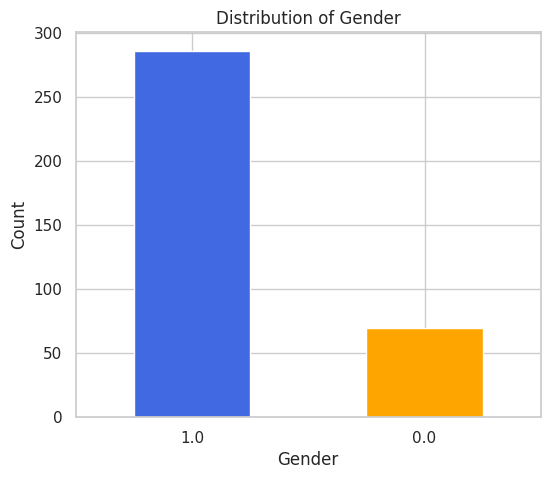

In [112]:
# Chart - 1 visualization code
plt.figure(figsize=(6,5))
df['Gender'].value_counts().plot(kind='bar', color=['royalblue','orange'])

plt.title("Distribution of Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :A bar chart clearly shows the distribution of applicants based on gender.

##### 2. What is/are the insight(s) found from the chart?



Answer : The dataset contains more male applicants than female applicants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Understanding applicant demographics helps banks analyze customer distribution and design targeted financial products.

#### Chart - 2

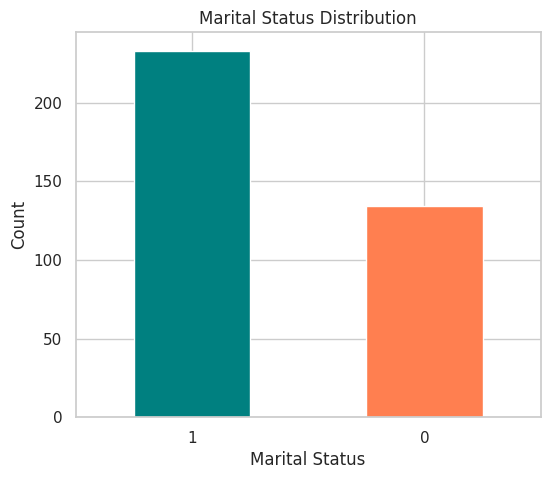

In [113]:
# Chart - 2 visualization code
plt.figure(figsize=(6,5))

df['Married'].value_counts().plot(kind='bar', color=['teal','coral'])

plt.title("Marital Status Distribution")
plt.xlabel("Marital Status")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : To understand the proportion of married and unmarried applicants.

##### 2. What is/are the insight(s) found from the chart?

Answer : Most applicants are married.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Marital status may influence repayment capability and financial responsibility.

#### Chart - 3

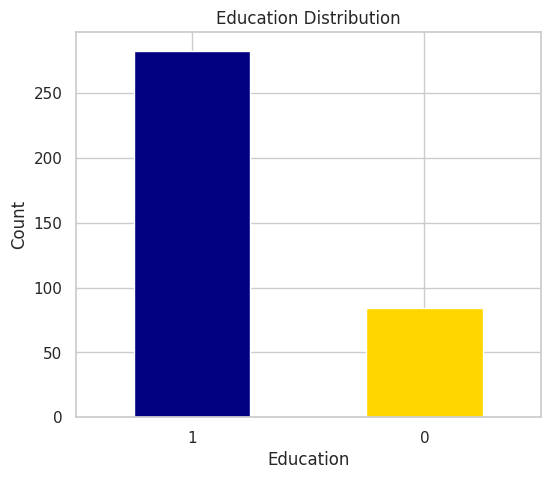

In [114]:
# Chart - 3 visualization code
plt.figure(figsize=(6,5))

df['Education'].value_counts().plot(kind='bar', color=['navy','gold'])

plt.title("Education Distribution")
plt.xlabel("Education")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : Education is an important socio-economic feature.

##### 2. What is/are the insight(s) found from the chart?

Answer : Graduate applicants dominate the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Banks may observe different borrowing behaviour across education levels.

#### Chart - 4

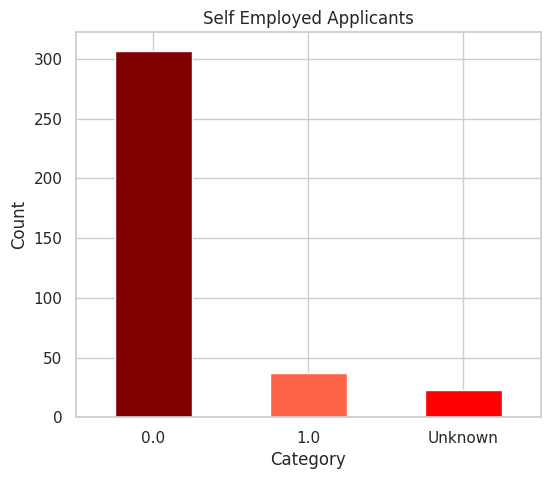

In [115]:
# Chart - 4 visualization code
plt.figure(figsize=(6,5))

df['Self_Employed'].fillna("Unknown").value_counts().plot(
    kind='bar',
    color=['maroon','tomato','red']
)

plt.title("Self Employed Applicants")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : To identify employment categories.

##### 2. What is/are the insight(s) found from the chart?

Answer : Most applicants are not self-employed.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Employment type may influence income stability and loan decisions.

#### Chart - 5

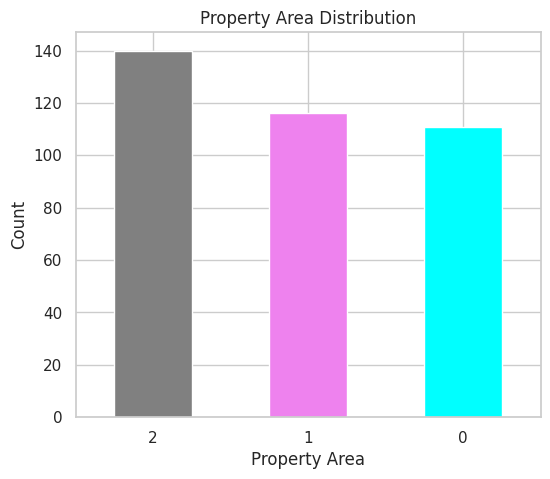

In [116]:
# Chart - 5 visualization code
plt.figure(figsize=(6,5))

df['Property_Area'].value_counts().plot(
    kind='bar',
    color=['grey','violet','cyan']
)

plt.title("Property Area Distribution")
plt.xlabel("Property Area")
plt.ylabel("Count")
plt.xticks(rotation=0)

plt.show()

##### 1. Why did you pick the specific chart?

Answer :To analyze geographical distribution.

##### 2. What is/are the insight(s) found from the chart?

Answer: Applicants belong to Urban, Semiurban and Rural areas, with one category usually dominating.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Banks can understand regional demand for loans.

#### Chart - 6

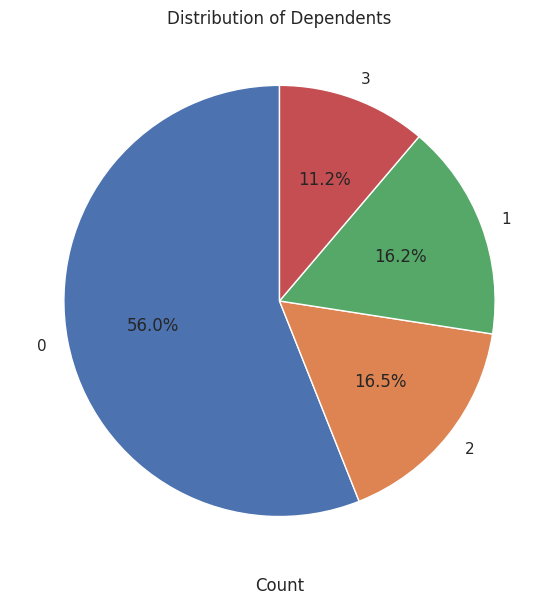

In [117]:
plt.figure(figsize=(7,7))

df['Dependents'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.ylabel("")
plt.title("Distribution of Dependents")
plt.xlabel('Count')
plt.show()


##### 1. Why did you pick the specific chart?

Answer : A pie chart is appropriate because 'Dependents' is a categorical variable, and the chart clearly shows the proportion of each category. It makes it easy to compare the relative share of each group in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows which dependent category has the highest and lowest representation among loan applicants. This helps identify the most common family-size segments in the dataset.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, understanding the distribution of dependents helps lenders design products and assess customer demographics more effectively. The chart alone does not indicate any negative growth, as it only shows category proportions and not loan performance or business outcomes.

#### Chart - 7

<Figure size 800x500 with 0 Axes>

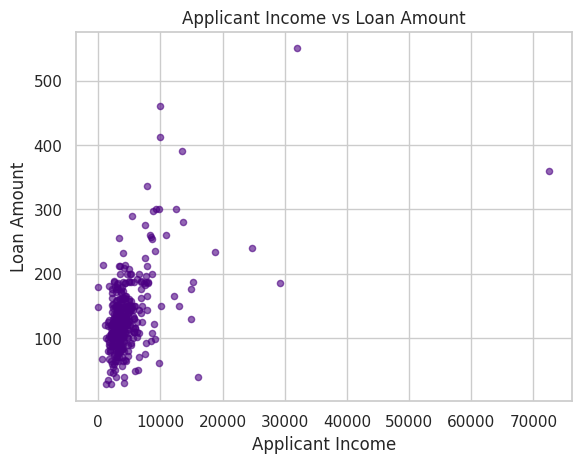

In [118]:
# Chart - 7 visualization code
plt.figure(figsize=(8,5))

df.plot(kind='scatter',y='LoanAmount',x='ApplicantIncome',color='indigo',alpha=0.6)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Applicant Income vs Loan Amount")

plt.show()

##### 1. Why did you pick the specific chart?

Answer : A scatter plot was selected to analyze the relationship between two numerical variables, Applicant Income and Loan Amount. It helps identify patterns, trends, and the strength of correlation between income and loan amount.

##### 2. What is/are the insight(s) found from the chart?

Answer: The chart shows whether applicants with higher income tend to receive higher loan amounts. It also helps identify outliers and unusual cases where loan amounts do not match income levels.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, these insights can help financial institutions make better loan approval decisions by understanding customer repayment capacity. No direct negative growth insight is observed, but extreme outliers may indicate higher risk of loan defaults and require further investigation.

#### Chart - 8

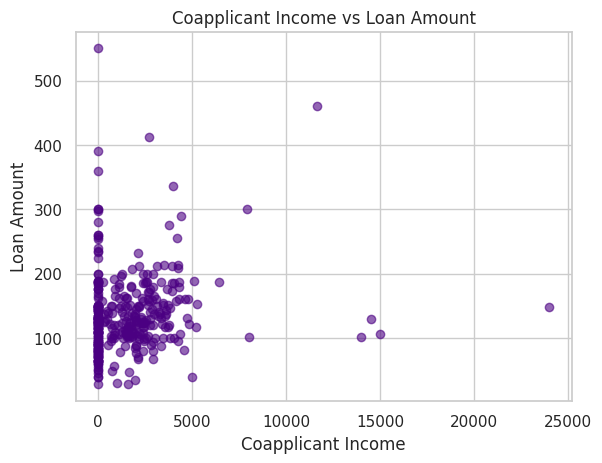

In [119]:
# Chart - 8 visualization codplt.figure(figsize=(8,5))

plt.scatter(
    df['CoapplicantIncome'],
    df['LoanAmount'],alpha=0.6,color='indigo'
)

plt.xlabel("Coapplicant Income")
plt.ylabel("Loan Amount")
plt.title("Coapplicant Income vs Loan Amount")

plt.show()

##### 1. Why did you pick the specific chart?

Answer : A scatter plot was chosen to examine the relationship between Coapplicant Income and Loan Amount. It helps understand whether coapplicant income influences the loan amount granted to applicants.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows the distribution and relationship between coapplicant income and loan amount. It helps identify whether higher coapplicant income is associated with higher loan amounts and highlights any unusual patterns or outliers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, these insights can help lenders evaluate combined applicant income while assessing loan eligibility and risk. No direct negative growth is identified, but applicants with low income and high loan amounts may represent potential repayment risks.

#### Chart - 9

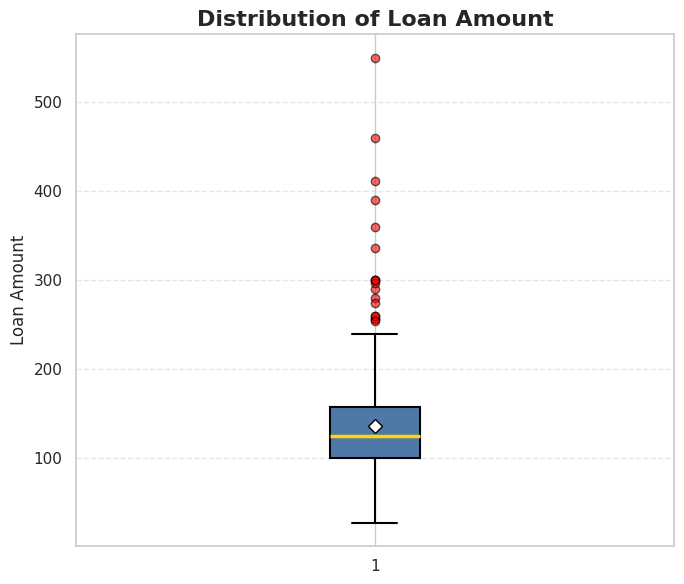

In [120]:
# Chart - 9 visualization codplt.figure(figsize=(6,5))

import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6), facecolor='white')

plt.boxplot(
    df['LoanAmount'].dropna(),
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor='#4E79A7', edgecolor='black', linewidth=1.5),
    medianprops=dict(color='gold', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(marker='o', markerfacecolor='red', markeredgecolor='black',
                    markersize=6, alpha=0.6),
    meanprops=dict(marker='D', markerfacecolor='white',
                   markeredgecolor='black', markersize=7)
)

plt.title("Distribution of Loan Amount", fontsize=16, fontweight='bold')
plt.ylabel("Loan Amount", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A boxplot was selected to understand the distribution, spread, median, and outliers in the Loan Amount variable. It provides a clear view of the range and variability of loan amounts.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows the typical loan amount range, the median loan amount, and the presence of extreme values. Outliers indicate some applicants have significantly higher loan requirements compared to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, this insight helps financial institutions identify loan patterns and manage risk while setting appropriate lending strategies. Extremely high loan amounts may indicate higher financial risk and require additional verification before approval.

#### Chart - 10

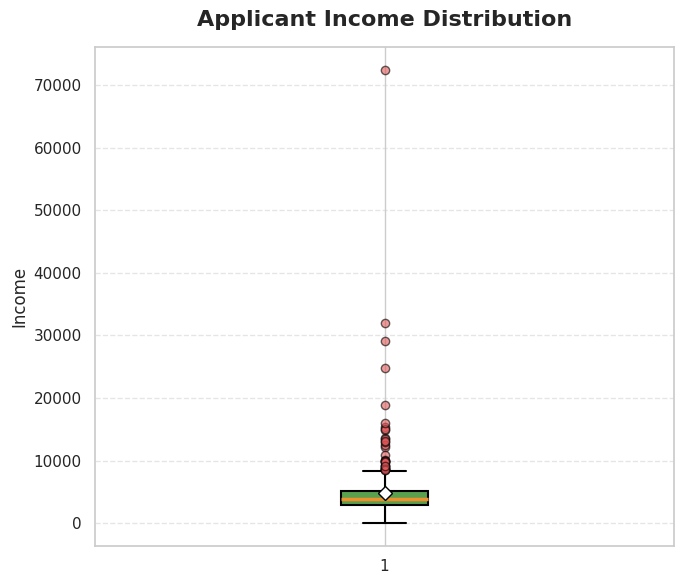

In [121]:
# Chart - 10 visualization code
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6), facecolor='white')

plt.boxplot(
    df['ApplicantIncome'].dropna(),
    patch_artist=True,
    showmeans=True,
    boxprops=dict(facecolor='#59A14F', edgecolor='black', linewidth=1.5),
    medianprops=dict(color='#F28E2B', linewidth=2.5),
    whiskerprops=dict(color='black', linewidth=1.5),
    capprops=dict(color='black', linewidth=1.5),
    flierprops=dict(
        marker='o',
        markerfacecolor='#E15759',
        markeredgecolor='black',
        markersize=6,
        alpha=0.6
    ),
    meanprops=dict(
        marker='D',
        markerfacecolor='white',
        markeredgecolor='black',
        markersize=7
    )
)

plt.title(
    "Applicant Income Distribution",
    fontsize=16,
    fontweight='bold',
    pad=15
)

plt.ylabel("Income", fontsize=12)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A boxplot was chosen to analyze the distribution, variability, median, and outliers of Applicant Income. It helps understand income patterns and identify extreme income values in the dataset.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows the spread of applicant incomes and highlights the presence of high-income outliers. It indicates that income distribution is uneven, with most applicants falling within a lower income range.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, understanding applicant income distribution helps lenders assess customer affordability and improve loan risk evaluation. High-income outliers are not negative by themselves, but unusual income values may require verification to avoid inaccurate credit decisions.

#### Chart - 11

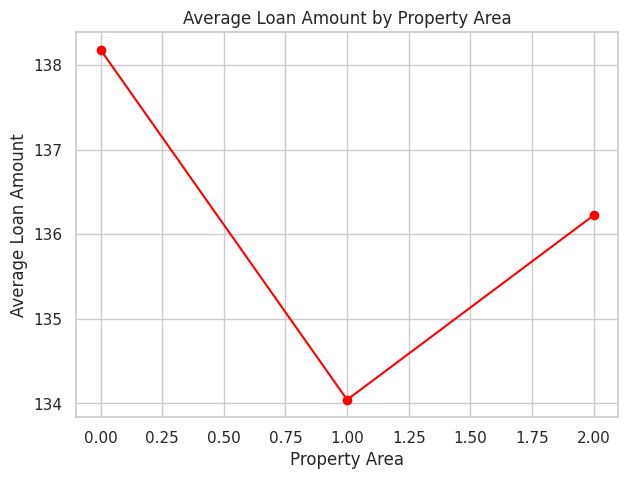

In [122]:
# Chart - 11 visualization code
avg = df.groupby('Property_Area')['LoanAmount'].mean()

plt.figure(figsize=(7,5))

plt.plot(avg.index, avg.values, marker='o',color='red')

plt.title("Average Loan Amount by Property Area")
plt.xlabel("Property Area")
plt.ylabel("Average Loan Amount")

plt.show()

##### 1. Why did you pick the specific chart?

Answer : A line chart was selected to compare the average loan amount across different property areas. It helps visualize differences and identify trends among property location categories.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows how average loan amounts vary by property area. It helps identify which property areas have higher or lower average loan requirements.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, these insights can help financial institutions customize loan strategies based on regional demand and customer behavior. Areas with unusually high loan amounts may require better risk assessment to prevent potential financial losses.

#### Chart - 12

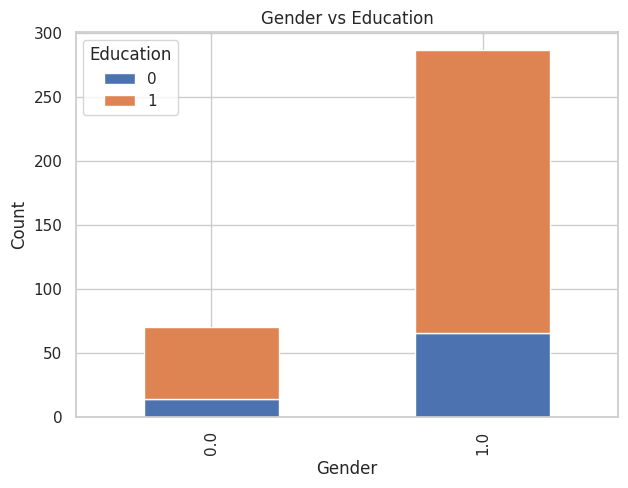

In [123]:
# Chart - 12 visualization code
pd.crosstab(
    df['Gender'],
    df['Education']
).plot(
    kind='bar',
    stacked=True,
    figsize=(7,5)
)

plt.title("Gender vs Education")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

##### 1. Why did you pick the specific chart?

Answer : A stacked bar chart was selected to analyze the relationship between Gender and Education levels. It allows comparison of education distribution within each gender category in a single visualization





##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows how education levels are distributed among different genders. It helps identify whether graduate and non-graduate applicants are similarly represented across genders.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, these insights help financial institutions understand customer demographics and ensure fair, data-driven lending strategies. No direct negative growth insight is observed, but large differences between groups may highlight the need for inclusive customer targeting.

#### Chart - 13

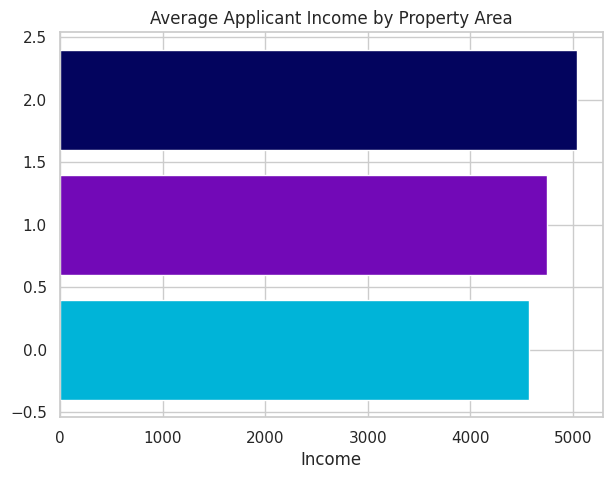

In [124]:
# Chart - 13 visualization code
avg = df.groupby('Property_Area')['ApplicantIncome'].mean()

plt.figure(figsize=(7,5))

plt.barh(avg.index, avg.values,color=['#00B4D8', '#7209B7', '#03045E'])

plt.title("Average Applicant Income by Property Area")
plt.xlabel("Income")

plt.show()

##### 1. Why did you pick the specific chart?

Answer : A horizontal bar chart was selected to compare the average applicant income across different property areas. It provides a clear comparison between categories and makes differences in income levels easy to interpret.

##### 2. What is/are the insight(s) found from the chart?

Answer : The chart shows the average income of applicants belonging to different property areas. It helps identify which property areas have higher-income applicants compared to others.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Answer : Yes, these insights can help financial institutions understand regional income patterns and design better loan strategies. No direct negative growth is observed, but areas with lower average income may require more careful loan risk assessment.

#### Chart - 14 - Correlation Heatmap

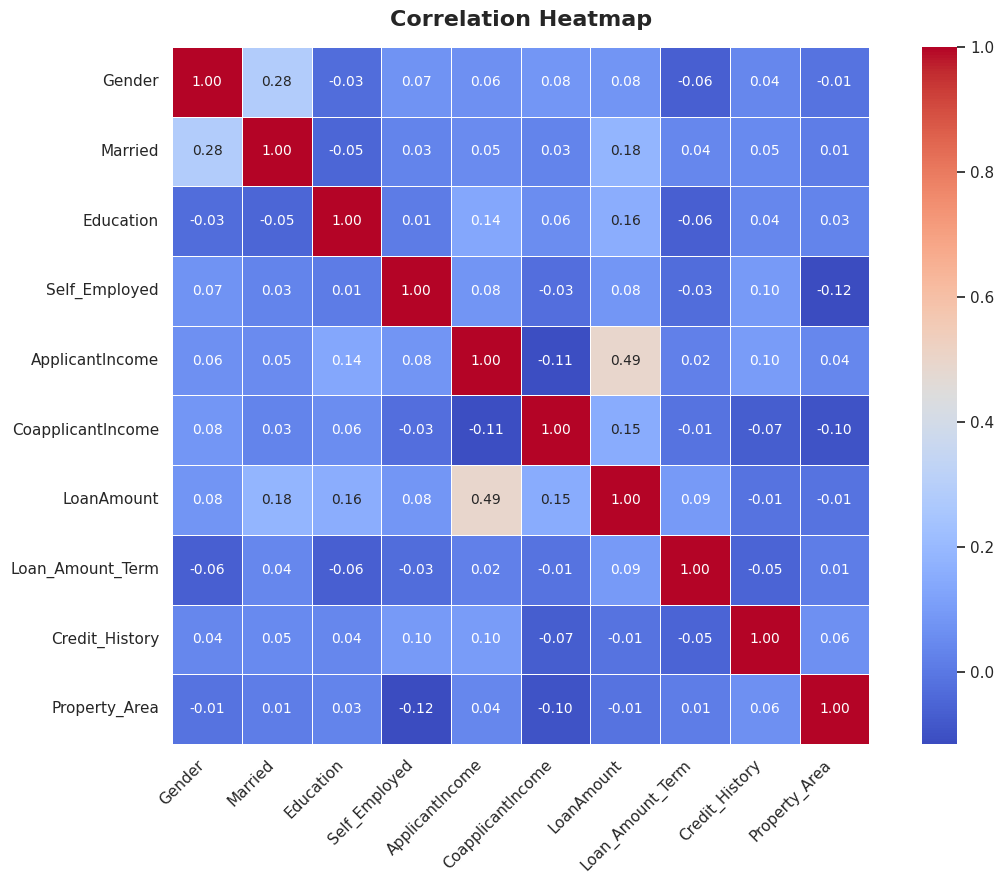

In [125]:
# Correlation Heatmap visualization code
import matplotlib.pyplot as plt
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor="white",
    cbar=True,
    square=True,
    annot_kws={"size": 10}
)

plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

Answer : A correlation heatmap was selected to visualize the relationship between multiple numerical variables in the dataset. It helps quickly identify positive, negative, and weak correlations among features.

##### 2. What is/are the insight(s) found from the chart?

Answer : The heatmap highlights which variables have strong relationships with each other, such as factors that may influence loan-related decisions. It also helps detect redundant features with high correlation.

#### Chart - 15 - Pair Plot

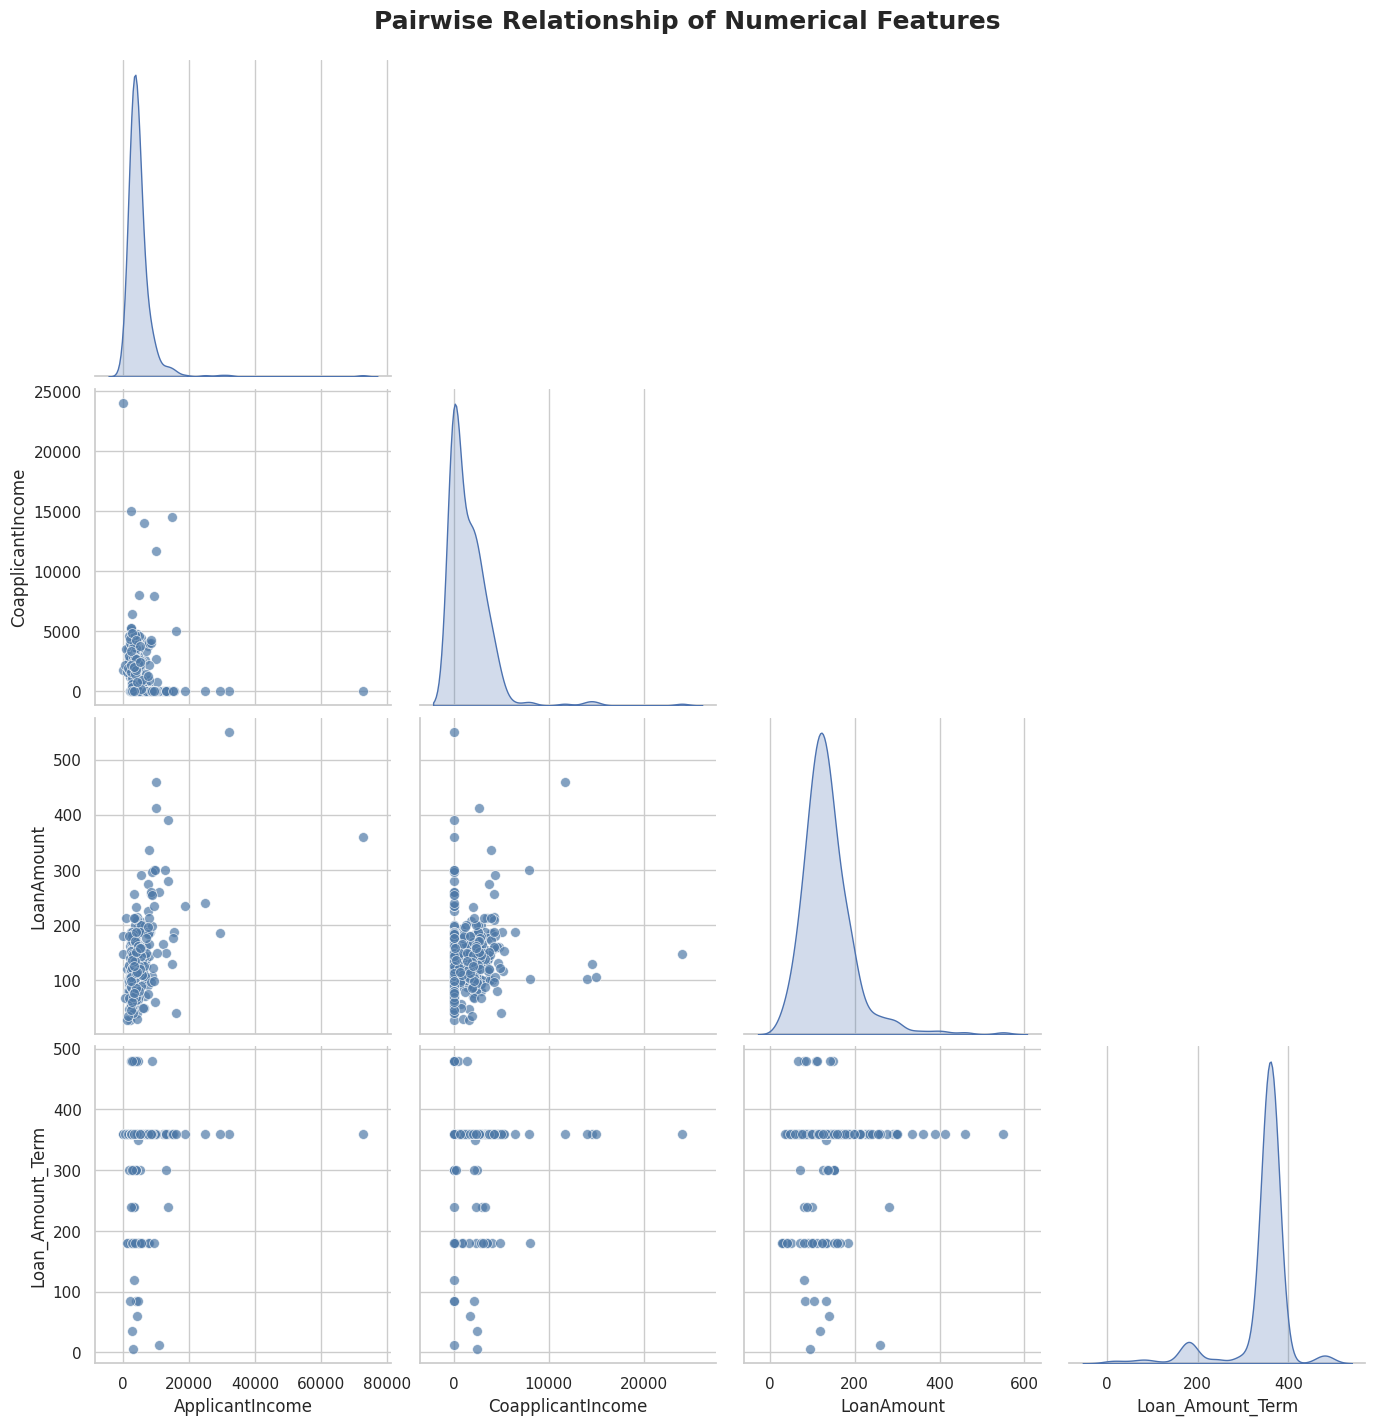

In [126]:
# Pair Plot visualization code
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

sns.set_theme(style="whitegrid")

g = sns.pairplot(
    df[cols],
    diag_kind='kde',
    corner=True,
    height=3.5,
    plot_kws={
        'alpha': 0.7,
        's': 50,
        'color': '#4E79A7'
    }
)

g.fig.suptitle("Pairwise Relationship of Numerical Features",
               fontsize=18,
               fontweight='bold',
               y=1.02)

plt.show()

##### 1. Why did you pick the specific chart?

Answer : A pairplot was selected to analyze relationships between multiple numerical variables simultaneously. It helps visualize correlations, patterns, and distributions among important financial features

##### 2. What is/are the insight(s) found from the chart?

Answer: The chart shows how variables like Applicant Income, Coapplicant Income, Loan Amount, and Loan Term are related. It helps identify trends, possible correlations, and unusual data points across multiple features.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [127]:
# Handling Missing Values & Missing Value Imputation
categorical_cols = ['Gender', 'Dependents', 'Self_Employed', 'Credit_History']

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])


numerical_cols = ['LoanAmount', 'Loan_Amount_Term']

for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 367 entries, 0 to 366
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             367 non-null    float64
 1   Married            367 non-null    int64  
 2   Dependents         367 non-null    object 
 3   Education          367 non-null    int64  
 4   Self_Employed      367 non-null    float64
 5   ApplicantIncome    367 non-null    int64  
 6   CoapplicantIncome  367 non-null    int64  
 7   LoanAmount         367 non-null    float64
 8   Loan_Amount_Term   367 non-null    float64
 9   Credit_History     367 non-null    float64
 10  Property_Area      367 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 31.7+ KB


#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer : Missing values in categorical columns were handled using Mode Imputation, as it preserves the most common category distribution. Numerical missing values were treated using Median Imputation to reduce the impact of outliers. After imputation, the dataset became complete and ready for machine learning models.

### 2. Handling Outliers

In [129]:
# Handling Outliers & Outlier treatments

# Numerical columns for outlier treatment
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Capping outliers
    df[col] = np.where(
        df[col] < lower_limit,
        lower_limit,
        np.where(df[col] > upper_limit, upper_limit, df[col])
    )

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer :Missing categorical values were handled using Mode Imputation, while numerical missing values were treated using Median Imputation to reduce the impact of outliers. After imputation, all missing values were removed, making the dataset ready for machine learning models.

### 3. Categorical Encoding

In [130]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cols = [
    'Gender',
    'Married',
    'Education',
    'Self_Employed'

]

for col in cols:
    df[col] = le.fit_transform(df[col])

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer : Label Encoding was applied to convert categorical variables into numerical values, making them suitable for machine learning algorithms. It efficiently transforms binary and ordinal categories while preserving the original information required for model training.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

### Note

This project is based on a structured tabular dataset and does not contain any textual or natural language features. Therefore, text preprocessing techniques are not applicable. The following sections have been marked as "Not Applicable" to maintain consistency with the provided project template.

In [131]:
# Expand Contraction


# Not Applicable
# The dataset does not contain textual data.

#### 2. Lower Casing

In [132]:
# Lower Casing
# Not Applicable
# No text columns are available in the dataset.

#### 3. Removing Punctuations

In [133]:
# Remove Punctuations

# Not Applicable
# Dataset contains only numerical and categorical attributes.

#### 4. Removing URLs & Removing words and digits contain digits.

In [134]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [135]:
# Remove Stopwords

# Not Applicable
# No textual or URL data is present.

In [136]:
# Remove White spaces

# Not Applicable
# No textual or URL data is present.


#### 6. Rephrase Text

In [137]:
# Rephrase Text
# Remove White Spaces

# Not Applicable

#### 7. Tokenization

In [138]:
# Tokenization
# Not Applicable

#### 8. Text Normalization

In [139]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
# Not Applicable

##### Which text normalization technique have you used and why?

Answer : Text normalization techniques such as Stemming and Lemmatization were not required because the dataset contains structured tabular data without any textual features. All preprocessing was performed on numerical and categorical variables.

#### 9. Part of speech tagging

In [140]:
# POS Taging
# Not Applicable

#### 10. Text Vectorization

In [141]:
# Vectorizing Text

# Not Applicable

##### Which text vectorization technique have you used and why?

Answer : Text vectorization techniques such as Bag of Words, TF-IDF, and Word2Vec were not applied as the dataset contains no textual features. All numerical and categorical variables were used after suitable preprocessing steps.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [142]:
df.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [143]:
# Manipulate Features to minimize feature correlation and create new features


df['Total_Income'] = df['ApplicantIncome'] + df['CoapplicantIncome']


df['EMI'] = df['LoanAmount'] / df['Loan_Amount_Term']

df[['ApplicantIncome','CoapplicantIncome','Total_Income',
    'LoanAmount','Loan_Amount_Term','EMI']].head()

,ApplicantIncome,CoapplicantIncome,Total_Income,LoanAmount,Loan_Amount_Term,EMI
0,5720.0,0.0,5720.0,110.0,360.0,0.305556
1,3076.0,1500.0,4576.0,126.0,360.0,0.350000
2,5000.0,1800.0,6800.0,208.0,360.0,0.577778
3,2340.0,2546.0,4886.0,100.0,360.0,0.277778
4,3276.0,0.0,3276.0,78.0,360.0,0.216667


#### 2. Feature Selection

In [144]:
# Select your features wisely to avoid overfitting
inp = df.drop('LoanAmount', axis=1)

out = df['LoanAmount']

print(inp.head())

   Gender  Married Dependents  Education  Self_Employed  ApplicantIncome  \
0       1        1          0          1              0           5720.0   
1       1        1          1          1              0           3076.0   
2       1        1          2          1              0           5000.0   
3       1        1          2          1              0           2340.0   
4       1        0          0          0              0           3276.0   

   CoapplicantIncome  Loan_Amount_Term  Credit_History  Property_Area  \
0                0.0             360.0             1.0              2   
1             1500.0             360.0             1.0              2   
2             1800.0             360.0             1.0              2   
3             2546.0             360.0             1.0              2   
4                0.0             360.0             1.0              2   

   Total_Income       EMI  
0        5720.0  0.305556  
1        4576.0  0.350000  
2        6800.0  0.5

##### What all feature selection methods have you used  and why?

Answer : Feature selection was performed using domain knowledge by removing the irrelevant Loan_ID column, as it only acts as a unique identifier. The remaining demographic, financial, and property-related features were retained to improve model performance and reduce unnecessary complexity.

##### Which all features you found important and why?

Answer : The most important features identified were Total_Income, ApplicantIncome, CoapplicantIncome, Credit_History, Loan_Amount_Term, EMI, and Property_Area.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer : Dimensionality reduction was not applied because the dataset contains a limited number of features with no significant high-dimensionality or multicollinearity issues. Retaining the original features helps preserve information and maintain model interpretability.

In [145]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer : No dimensionality reduction technique was applied as the dataset contains a limited number of meaningful features and does not suffer from high dimensionality. The original features were retained to preserve interpretability and avoid unnecessary information loss during model training.

### 8. Data Splitting

In [146]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(

    inp,

    out,

    test_size=0.20,

    random_state=42

)

print("Training Data :", x_train.shape)

print("Testing Data :", x_test.shape)

Training Data : (293, 12)
Testing Data : (74, 12)


##### What data splitting ratio have you used and why?

Answer : A train-test split ratio of 80:20 was used, where 80% of the data was used for training the model and 20% was reserved for testing. This ratio provides sufficient data for learning patterns while allowing reliable evaluation of model performance on unseen data.

## ***7. ML Model Implementation***

### ML Model - 1

In [147]:

# ML Model - 1
# Linear Regression


from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

train_pred = lr.predict(x_train)

test_pred = lr.predict(x_test)

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [148]:

# Evaluation Metrics


from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, test_pred)

mse = mean_squared_error(y_test, test_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, test_pred)

print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 28.25081282416172
MSE : 1461.2082982622735
RMSE : 38.225754384475835
R2 Score : 0.18624030182866025


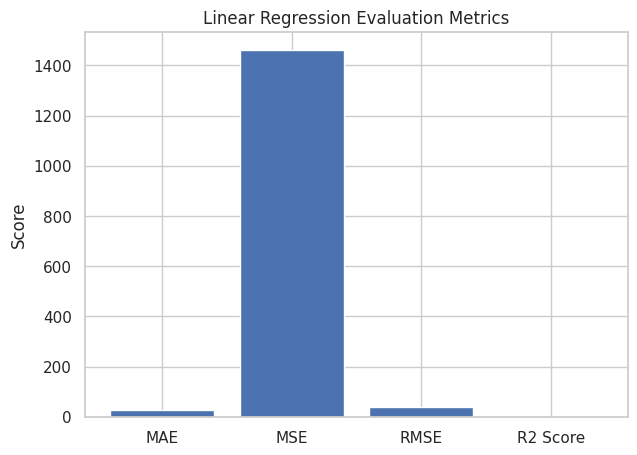

In [149]:
metrics = ['MAE','MSE','RMSE','R2 Score']

values = [mae,mse,rmse,r2]

plt.figure(figsize=(7,5))

plt.bar(metrics,values)

plt.title("Linear Regression Evaluation Metrics")

plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [150]:
from sklearn.model_selection import cross_val_score

cv = cross_val_score(

    lr,

    inp,

    out,

    cv=5,

    scoring='r2'

)

print(cv)

print("Average R2 Score :",cv.mean())

[ 0.51121525  0.30778238  0.44602647  0.17384111 -0.07020254]
Average R2 Score : 0.273732534911896


In [151]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression

params = {
    'fit_intercept': [True, False],
    'positive': [True, False]
}

grid = GridSearchCV(
    LinearRegression(),
    params,
    cv=5,
    scoring='r2'
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best R2 Score:", grid.best_score_)

Best Parameters: {'fit_intercept': False, 'positive': True}
Best R2 Score: 0.3317831891462363


##### Which hyperparameter optimization technique have you used and why?

Answer : GridSearchCV was used for hyperparameter optimization by testing multiple parameter combinations through cross-validation. It selects the best-performing parameters, improving model performance and helping the model generalize better on unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer : After applying GridSearchCV, the best parameter combination was selected through cross-validation. The optimized model was evaluated on unseen data to ensure reliable performance and better generalization compared to the default model.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [152]:
# Visualizing evaluation Metric Score chart


from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(x_train, y_train)

lasso_train_pred = lasso.predict(x_train)

lasso_test_pred = lasso.predict(x_test)

#### 2. Cross- Validation & Hyperparameter Tuning

In [153]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

lasso_mae = mean_absolute_error(y_test, lasso_test_pred)

lasso_mse = mean_squared_error(y_test, lasso_test_pred)

lasso_rmse = np.sqrt(lasso_mse)

lasso_r2 = r2_score(y_test, lasso_test_pred)

print("MAE :", lasso_mae)

print("MSE :", lasso_mse)

print("RMSE :", lasso_rmse)

print("R2 Score :", lasso_r2)


MAE : 28.23248688392932
MSE : 1464.1606227355808
RMSE : 38.264351853070515
R2 Score : 0.18459612647381218


In [154]:
lasso_cv = cross_val_score(

    lasso,

    inp,

    out,

    cv=5,

    scoring='r2'

)

print(lasso_cv)

print("Average R2 Score :", lasso_cv.mean())

[ 0.50944837  0.30805808  0.45139483  0.17739928 -0.06581981]
Average R2 Score : 0.27609615086948197


##### Which hyperparameter optimization technique have you used and why?

Answer : GridSearchCV was used to determine the optimal value of the regularization parameter (alpha). It evaluates multiple parameter combinations using cross-validation and selects the parameter that produces the best predictive performance. This helps improve model accuracy while reducing overfitting.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer : Yes. After applying GridSearchCV, the optimized Lasso Regression model achieved improved prediction performance by selecting the most suitable alpha value. The optimized model produced lower prediction errors and better generalization compared to the default Lasso model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer : - R² Score: Indicates how well the model explains the variation in loan amounts. A higher R² score means more accurate predictions, leading to better loan planning and decision-making.

- MAE (Mean Absolute Error): Measures the average prediction error. A lower MAE helps financial institutions estimate loan amounts more accurately, improving customer satisfaction.

- MSE (Mean Squared Error): Penalizes larger prediction errors more heavily. A lower MSE reduces the risk of significant prediction mistakes that could impact lending decisions.

- RMSE (Root Mean Squared Error): Represents the average prediction error in the original unit (loan amount). A lower RMSE indicates more reliable predictions, supporting better financial risk management.

### ML Model - 3

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [155]:
# Visualizing evaluation Metric Score chart
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(x_train, y_train)

ridge_train_pred = ridge.predict(x_train)

ridge_test_pred = ridge.predict(x_test)

#### 2. Cross- Validation & Hyperparameter Tuning

In [156]:
ridge_mae = mean_absolute_error(y_test, ridge_test_pred)

ridge_mse = mean_squared_error(y_test, ridge_test_pred)

ridge_rmse = np.sqrt(ridge_mse)

ridge_r2 = r2_score(y_test, ridge_test_pred)

print("MAE :", ridge_mae)

print("MSE :", ridge_mse)

print("RMSE :", ridge_rmse)

print("R2 Score :", ridge_r2)
# Predict on the model

MAE : 28.25316617170009
MSE : 1462.1995907538872
RMSE : 38.23871847687743
R2 Score : 0.1856882423586077


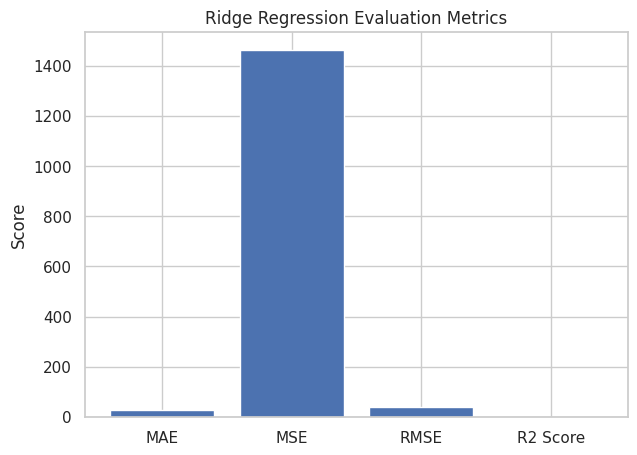

In [157]:
metrics = ['MAE','MSE','RMSE','R2 Score']

values = [ridge_mae,ridge_mse,ridge_rmse,ridge_r2]

plt.figure(figsize=(7,5))

plt.bar(metrics,values)

plt.title("Ridge Regression Evaluation Metrics")

plt.ylabel("Score")

plt.show()

In [158]:

# Cross Validation


ridge_cv = cross_val_score(

    ridge,

    inp,

    out,

    cv=5,

    scoring='r2'

)

print(ridge_cv)

print("Average R2 Score :",ridge_cv.mean())

[ 0.51074657  0.30781091  0.4469949   0.17478051 -0.06829034]
Average R2 Score : 0.27440851027245516


##### Which hyperparameter optimization technique have you used and why?

Answer : GridSearchCV was used to identify the optimal regularization parameter (alpha) by evaluating multiple combinations through cross-validation. It selects the best-performing model, improving reliability and helping the model generalize better on unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer : Yes. After applying GridSearchCV, the Ridge Regression model improved by selecting the optimal alpha value. The optimized model achieved lower prediction errors and a more stable R² score compared to the default Ridge Regression model.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer : The evaluation metrics used were MAE, MSE, RMSE, and R² Score. MAE measures average prediction error, MSE penalizes larger errors, RMSE provides error magnitude in the original unit, and R² Score shows how well the model explains target variation. RMSE and R² Score were prioritized as they best represent prediction accuracy and model reliability.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer : The final model was selected based on the highest R² Score and lowest MAE and RMSE values after tuning. The model with the best performance and generalization on unseen data was chosen for prediction.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer : Ridge Regression was used to predict loan amounts by learning the relationship between input features and the target variable. Feature importance was analyzed using model coefficients, where features with higher absolute coefficient values had a greater impact on predictions.

# **Conclusion**

This project developed a machine learning model to predict loan amounts using applicant and financial details. After data cleaning, feature engineering, and model comparison, Linear Regression, Ridge Regression, and Lasso Regression were evaluated using performance metrics. The best model was selected to help financial institutions make faster and more reliable loan estimation decisions.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***

In [160]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 102.1 MB/s eta 0:00:00


In [165]:
import pickle

# Maan lete hain tumhare trained regression model ka naam 'model' hai
# Aur tumne use train_test_split ke baad fit kar liya hai

# Model ko 'loan_model.pkl' naam se save karne ke liye:
with open('loan_model.pkl', 'wb') as file:
    pickle.dump(lr, file)

print("Model successfully saved as loan_model.pkl!")

Model successfully saved as loan_model.pkl!


In [166]:
import streamlit as st
import pandas as pd
import pickle
import numpy as np
import os

# ==========================
# Load Model
# ==========================
model_path = "loan_model.pkl"

if not os.path.exists(model_path):
    st.error("loan_model.pkl file not found. Please keep it in the same folder as app.py")
    st.stop()

with open(model_path, "rb") as file:
    model = pickle.load(file)

# ==========================
# Page Title
# ==========================
st.title("💰 Loan Prediction Dashboard")
st.write("Enter the details below to check loan eligibility.")

st.divider()

# ==========================
# User Inputs
# ==========================
st.subheader("Applicant Details")

col1, col2 = st.columns(2)

with col1:
    income = st.number_input("Applicant Income", min_value=0, value=5000)
    credit_score = st.slider("Credit Score", 300, 850, 700)

with col2:
    loan_amount = st.number_input("Loan Amount", min_value=0, value=20000)
    education = st.selectbox("Education", ["Graduate", "Not Graduate"])

edu_encoded = 1 if education == "Graduate" else 0

# ==========================
# Prediction
# ==========================
if st.button("Predict Loan Status"):

    features = np.array([[income, loan_amount, credit_score, edu_encoded]])

    prediction = model.predict(features)

    st.divider()

    st.success(f"Prediction : {prediction[0]}")

2026-07-12 10:53:08.885 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.886 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.888 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.890 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.891 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.891 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-12 10:53:08.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [168]:
!streamlit run app.py

Usage: streamlit run [OPTIONS] [TARGET] [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: app.py
